# Tutorial: Mann-Kendall Trend Analysis with Real GPCP Precipitation

Audience:
- Users who want to compare Skyborn against loop-based regression and Mann-Kendall baselines on a real global precipitation dataset.

Prerequisites:
- Local GPCP monthly precipitation file at `GPCP.precip.mon.mean.nc`
- `cartopy`, `scipy`, `pymannkendall`, and `cmaps` available in the active environment

Learning goals:
- Load and prepare a real monthly precipitation dataset from GPCP
- Benchmark four common trend-analysis workflows on annual means
- Compare multiple Mann-Kendall test families on the same precipitation field
- Visualize significance masks with `skyborn.plot.scatter`


## Outline

1. Setup and load the real GPCP dataset
2. Build annual-mean precipitation for `1979-2014`
3. Benchmark four methods with the same 2D layout
4. Compare additional Mann-Kendall test families on annual GPCP trends
5. Compare seasonal Mann-Kendall families on monthly GPCP data


In [ ]:
from __future__ import annotations

from pathlib import Path
import time
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmaps
import matplotlib.pyplot as plt
import numpy as np
import pymannkendall as pmk
import xarray as xr
from scipy import stats

from skyborn.calc import linear_regression, mann_kendall_multidim, mann_kendall_xarray
from skyborn.plot import scatter

DATA_PATH = Path(r"GPCP.precip.mon.mean.nc")
FIGURE_DIR = Path(r"../images")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"GPCP file not found: {DATA_PATH}. Update DATA_PATH before running this notebook."
    )

warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in sqrt")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

TREND_SCALE = 100.0
TREND_MAX = 5.0
LEVELS = np.linspace(-TREND_MAX, TREND_MAX, 21)
CMAP = cmaps.BlueWhiteOrangeRed
NORM = plt.Normalize(vmin=-TREND_MAX, vmax=TREND_MAX)
SIG_LEVEL = 0.05


## Step 1 - Load GPCP monthly precipitation

The file contains monthly `precip(time, lat, lon)` in `mm/day`. We keep the full monthly record for seasonal Mann-Kendall tests and build annual means for the four-method benchmark and the annual MK families.


In [13]:
gpcp = xr.open_dataset(DATA_PATH)
pr_monthly = gpcp["precip"].sel(time=slice("1979", "2014")).load()
pr_annual = pr_monthly.groupby("time.year").mean("time")

gpcp


<xarray.Dataset> Size: 23MB
Dimensions:    (time: 548, nv: 2, lat: 72, lon: 144)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-08-01
  * lat        (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon        (lon) float32 576B 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 9kB ...
    lat_bnds   (lat, nv) float32 576B ...
    lon_bnds   (lon, nv) float32 1kB ...
    precip     (time, lat, lon) float32 23MB ...
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2024/07 through latest.

In [14]:
print(f"Monthly subset shape: {pr_monthly.shape} {pr_monthly.dims}")
print(f"Annual mean shape: {pr_annual.shape} {pr_annual.dims}")
print(f"Units: {pr_monthly.attrs.get('units', 'unknown')}")
print(f"Year range: {int(pr_annual['year'].min())} - {int(pr_annual['year'].max())}")
print(f"Latitude size: {pr_annual.sizes['lat']}, longitude size: {pr_annual.sizes['lon']}")
print(f"Annual missing values: {int(pr_annual.isnull().sum())}")


Monthly subset shape: (432, 72, 144) ('time', 'lat', 'lon')
Annual mean shape: (36, 72, 144) ('year', 'lat', 'lon')
Units: mm/day
Year range: 1979 - 2014
Latitude size: 72, longitude size: 144
Annual missing values: 0


## Step 2 - Benchmark four methods on the same annual field

This section keeps the same layout you were already using:

- Skyborn `linear_regression`
- SciPy `stats.linregress` loop
- Skyborn `mann_kendall_multidim(..., test="original")`
- `pymannkendall.original_test` loop

All four methods use the same annual GPCP field and the same significance threshold.


In [15]:
def benchmark_four_methods(pr_annual: xr.DataArray) -> dict[str, object]:
    pr = pr_annual.values.astype(np.float64)
    year = pr_annual["year"].values.astype(np.float64)
    lat = pr_annual["lat"].values
    lon = pr_annual["lon"].values

    start_time = time.perf_counter()
    pr_trend_skyborn, p_values_skyborn = linear_regression(pr, year)
    time_skyborn = time.perf_counter() - start_time

    pr_trend_scipy = np.full((len(lat), len(lon)), np.nan, dtype=np.float64)
    p_values_scipy = np.full((len(lat), len(lon)), np.nan, dtype=np.float64)
    start_time = time.perf_counter()
    for i in range(len(lat)):
        for j in range(len(lon)):
            series = pr[:, i, j]
            if np.isfinite(series).all():
                slope, intercept, r_value, p_value, std_err = stats.linregress(year, series)
                pr_trend_scipy[i, j] = slope
                p_values_scipy[i, j] = p_value
    time_scipy = time.perf_counter() - start_time

    start_time = time.perf_counter()
    mk_result = mann_kendall_multidim(pr, axis=0, test="original", method="theilslopes")
    time_mk_skyborn = time.perf_counter() - start_time
    pr_trend_mk_skyborn = mk_result["trend"]
    p_values_mk_skyborn = mk_result["p"]

    pr_trend_pmk = np.full((len(lat), len(lon)), np.nan, dtype=np.float64)
    p_values_pmk = np.full((len(lat), len(lon)), np.nan, dtype=np.float64)
    start_time = time.perf_counter()
    for i in range(len(lat)):
        for j in range(len(lon)):
            series = pr[:, i, j]
            if np.isfinite(series).all():
                result = pmk.original_test(series)
                pr_trend_pmk[i, j] = result.slope
                p_values_pmk[i, j] = result.p
    time_pmk = time.perf_counter() - start_time

    return {
        "lat": lat,
        "lon": lon,
        "timings": {
            "Skyborn linear_regression": time_skyborn,
            "SciPy linear regression": time_scipy,
            "Skyborn Mann-Kendall": time_mk_skyborn,
            "PyMannKendall": time_pmk,
        },
        "fields": {
            "Skyborn linear_regression": {
                "trend": pr_trend_skyborn * TREND_SCALE,
                "p": p_values_skyborn,
            },
            "SciPy linear regression": {
                "trend": pr_trend_scipy * TREND_SCALE,
                "p": p_values_scipy,
            },
            "Skyborn Mann-Kendall": {
                "trend": pr_trend_mk_skyborn * TREND_SCALE,
                "p": p_values_mk_skyborn,
            },
            "PyMannKendall": {
                "trend": pr_trend_pmk * TREND_SCALE,
                "p": p_values_pmk,
            },
        },
        "consistency": {
            "linear_trend_max_abs": float(np.nanmax(np.abs(pr_trend_skyborn - pr_trend_scipy))),
            "linear_p_max_abs": float(np.nanmax(np.abs(p_values_skyborn - p_values_scipy))),
            "mk_trend_max_abs": float(np.nanmax(np.abs(pr_trend_mk_skyborn - pr_trend_pmk))),
            "mk_p_max_abs": float(np.nanmax(np.abs(p_values_mk_skyborn - p_values_pmk))),
        },
    }


def plot_trend_panel(ax, lon, lat, trend, p_values, title):
    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, color="lightgray", alpha=0.5)
    im = ax.contourf(
        lon,
        lat,
        trend,
        levels=LEVELS,
        cmap=CMAP,
        norm=NORM,
        transform=ccrs.PlateCarree(),
        extend="both",
    )
    scatter(
        ax,
        lon,
        lat,
        where=np.isfinite(p_values) & (p_values < SIG_LEVEL),
        density=2.0,
        s=1,
        c="black",
        alpha=0.55,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title, fontweight="bold")
    return im


benchmark = benchmark_four_methods(pr_annual)
benchmark["timings"], benchmark["consistency"]


({'Skyborn linear_regression': 0.009161099995253608,
  'SciPy linear regression': 3.171522399992682,
  'Skyborn Mann-Kendall': 0.15956569999980275,
  'PyMannKendall': 17.354746500001056},
 {'linear_trend_max_abs': 3.755242644620793e-15,
  'linear_p_max_abs': 2.2426505097428162e-14,
  'mk_trend_max_abs': 1.3877787807814457e-17,
  'mk_p_max_abs': 0.0})

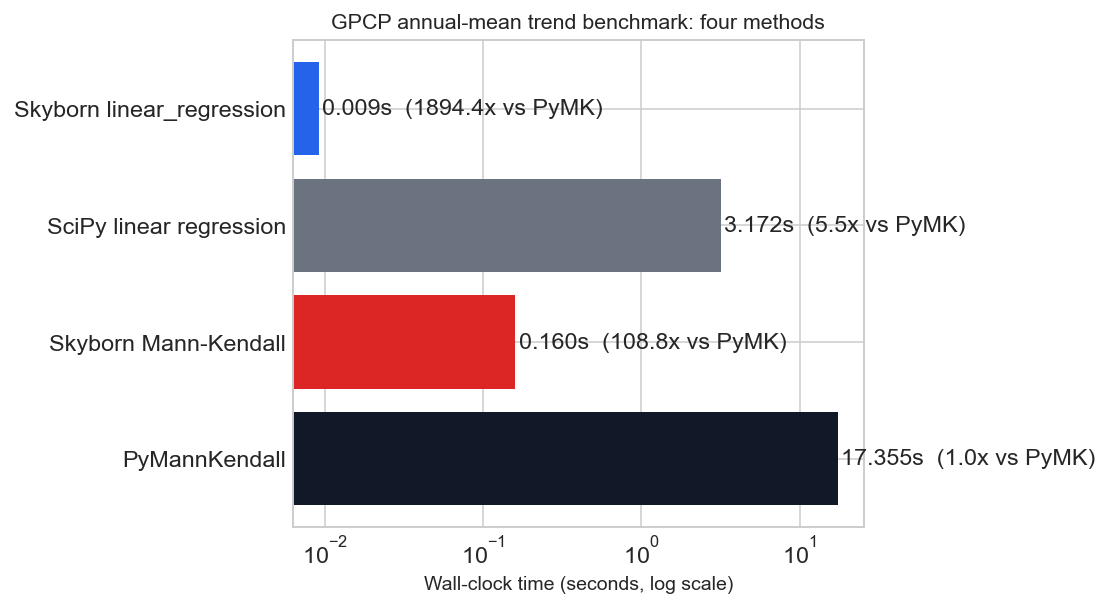

In [16]:
labels = list(benchmark["timings"].keys())
times = np.array(list(benchmark["timings"].values()), dtype=float)
speedup_vs_pmk = benchmark["timings"]["PyMannKendall"] / times

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_colors = ["#2563eb", "#6b7280", "#dc2626", "#111827"]
bars = ax.barh(labels, times, color=bar_colors)
ax.set_xscale("log")
ax.set_xlabel("Wall-clock time (seconds, log scale)")
ax.set_title("GPCP annual-mean trend benchmark: four methods")
ax.invert_yaxis()
for bar, t, s in zip(bars, times, speedup_vs_pmk):
    ax.text(t * 1.05, bar.get_y() + bar.get_height() / 2, f"{t:.3f}s  ({s:.1f}x vs PyMK)", va="center")
plt.tight_layout()
plt.show()


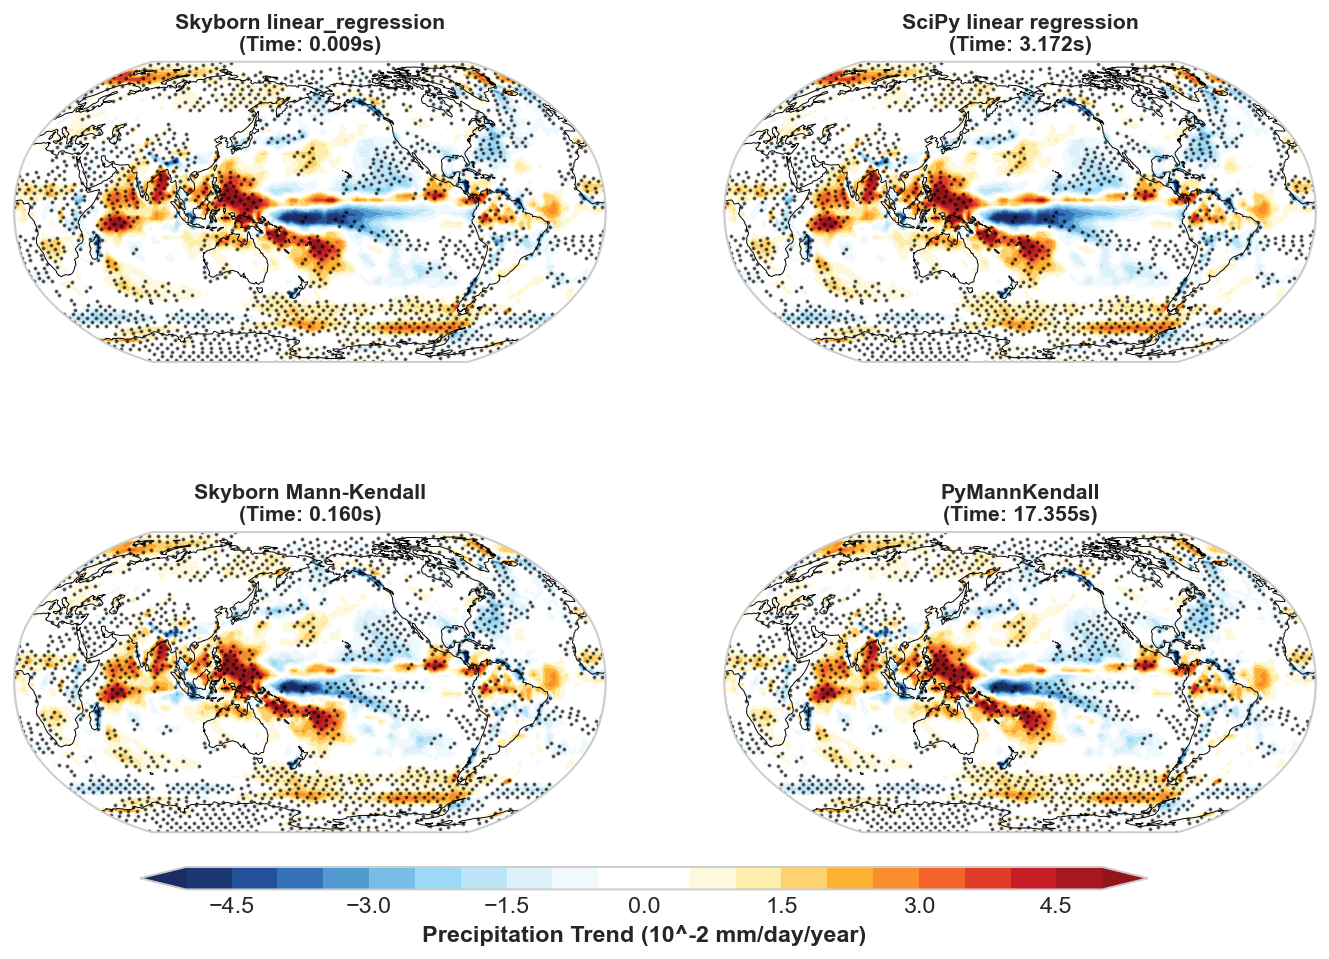

In [17]:
lon = benchmark["lon"]
lat = benchmark["lat"]

fig = plt.figure(figsize=(12, 8))

ax1 = plt.subplot(2, 2, 1, projection=ccrs.Robinson(central_longitude=180))
im1 = plot_trend_panel(
    ax1,
    lon,
    lat,
    benchmark["fields"]["Skyborn linear_regression"]["trend"],
    benchmark["fields"]["Skyborn linear_regression"]["p"],
    f"Skyborn linear_regression\n(Time: {benchmark['timings']['Skyborn linear_regression']:.3f}s)",
)

ax2 = plt.subplot(2, 2, 2, projection=ccrs.Robinson(central_longitude=180))
plot_trend_panel(
    ax2,
    lon,
    lat,
    benchmark["fields"]["SciPy linear regression"]["trend"],
    benchmark["fields"]["SciPy linear regression"]["p"],
    f"SciPy linear regression\n(Time: {benchmark['timings']['SciPy linear regression']:.3f}s)",
)

ax3 = plt.subplot(2, 2, 3, projection=ccrs.Robinson(central_longitude=180))
plot_trend_panel(
    ax3,
    lon,
    lat,
    benchmark["fields"]["Skyborn Mann-Kendall"]["trend"],
    benchmark["fields"]["Skyborn Mann-Kendall"]["p"],
    f"Skyborn Mann-Kendall\n(Time: {benchmark['timings']['Skyborn Mann-Kendall']:.3f}s)",
)

ax4 = plt.subplot(2, 2, 4, projection=ccrs.Robinson(central_longitude=180))
plot_trend_panel(
    ax4,
    lon,
    lat,
    benchmark["fields"]["PyMannKendall"]["trend"],
    benchmark["fields"]["PyMannKendall"]["p"],
    f"PyMannKendall\n(Time: {benchmark['timings']['PyMannKendall']:.3f}s)",
)

cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar = plt.colorbar(im1, cax=cbar_ax, orientation="horizontal", extend="both")
cbar.set_label("Precipitation Trend (10^-2 mm/day/year)", fontweight="bold", fontsize=12)
plt.show()


## Step 3 - Additional annual Mann-Kendall test families

The next figure switches away from the four-method benchmark and focuses only on Skyborn's Mann-Kendall family support. These annual tests all use the same annual GPCP field, but they differ in how they handle serial correlation before estimating significance.


In [18]:
annual_test_labels = {
    "original": "Original",
    "yue_wang": "Yue-Wang",
    "hamed_rao": "Hamed-Rao",
    "pre_whitening": "Pre-whitening",
    "trend_free_pre_whitening": "Trend-free pre-whitening",
}

annual_family_results = {}
for test_name in annual_test_labels:
    start_time = time.perf_counter()
    result = mann_kendall_xarray(pr_annual, dim="year", test=test_name, use_dask=False)
    annual_family_results[test_name] = {
        "result": result,
        "elapsed": time.perf_counter() - start_time,
    }

{
    key: {
        "time_s": round(value["elapsed"], 3),
        "trend_mean": float(value["result"]["trend"].mean().values),
        "p_mean": float(value["result"]["p"].mean().values),
    }
    for key, value in annual_family_results.items()
}


{'original': {'time_s': 0.131,
  'trend_mean': 0.0005843882468302479,
  'p_mean': 0.30874893760779976},
 'yue_wang': {'time_s': 0.133,
  'trend_mean': 0.0005843882468302479,
  'p_mean': 0.14570934915756303},
 'hamed_rao': {'time_s': 0.188,
  'trend_mean': 0.0005843882468302479,
  'p_mean': 0.301690559168806},
 'pre_whitening': {'time_s': 0.136,
  'trend_mean': 0.0005843882468302479,
  'p_mean': 0.3460342612478936},
 'trend_free_pre_whitening': {'time_s': 0.138,
  'trend_mean': 0.0005843882468302479,
  'p_mean': 0.3026199075317609}}

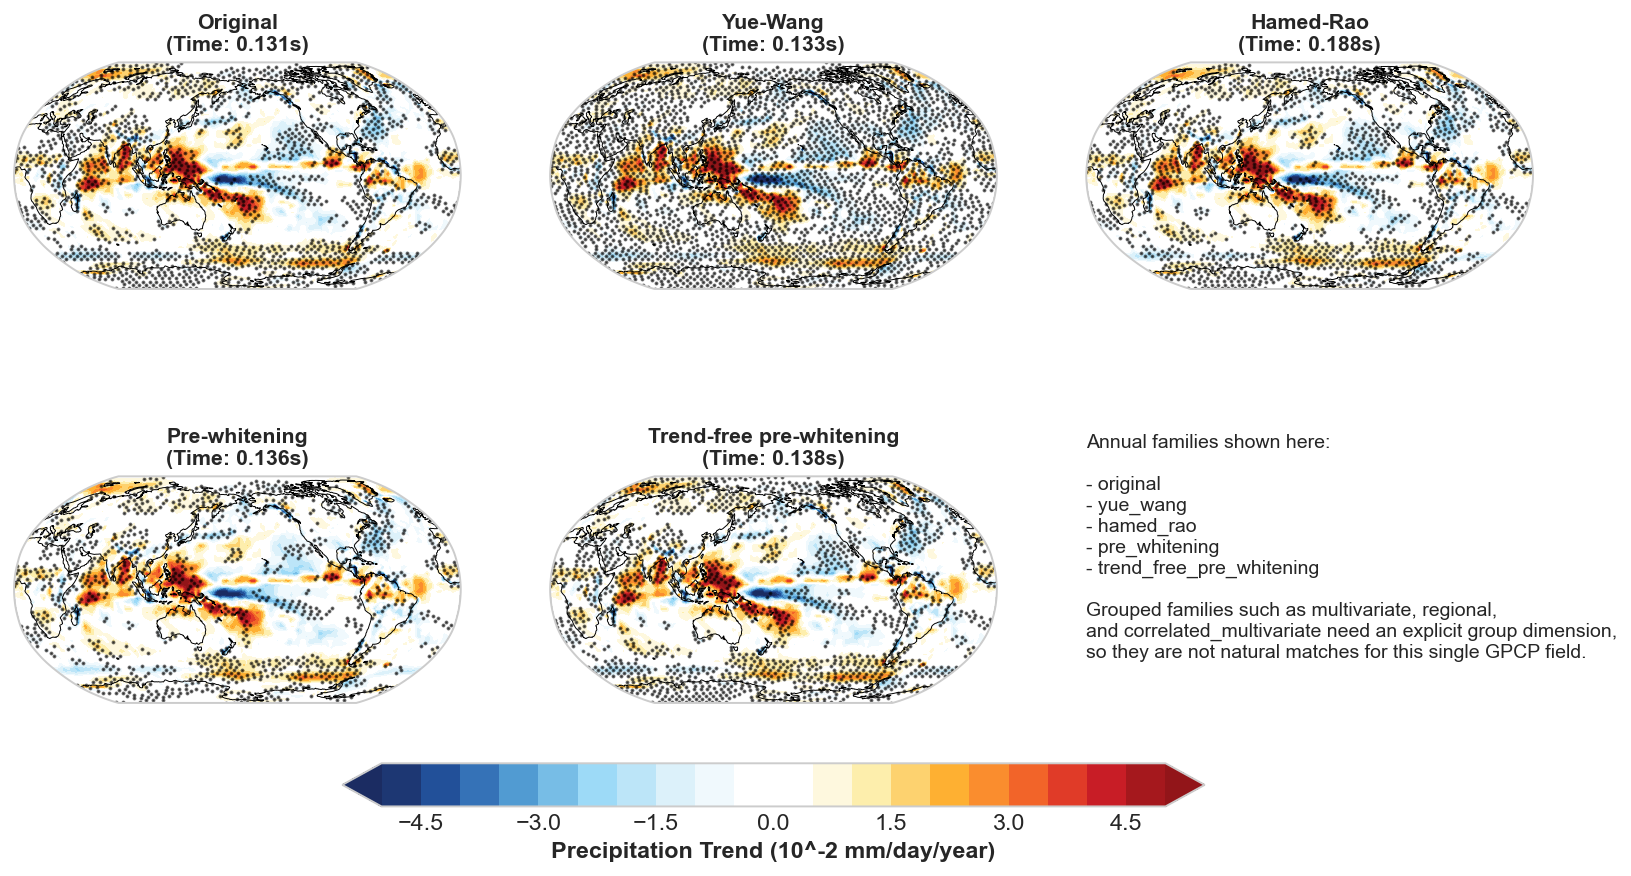

In [19]:
fig = plt.figure(figsize=(14, 8))
for idx, (test_name, label) in enumerate(annual_test_labels.items(), start=1):
    ax = plt.subplot(2, 3, idx, projection=ccrs.Robinson(central_longitude=180))
    ds = annual_family_results[test_name]["result"]
    im = plot_trend_panel(
        ax,
        ds["lon"].values,
        ds["lat"].values,
        ds["trend"].values * TREND_SCALE,
        ds["p"].values,
        f"{label}\n(Time: {annual_family_results[test_name]['elapsed']:.3f}s)",
    )

ax_note = plt.subplot(2, 3, 6)
ax_note.axis("off")
ax_note.text(
    0.0,
    0.95,
    """Annual families shown here:

- original
- yue_wang
- hamed_rao
- pre_whitening
- trend_free_pre_whitening

Grouped families such as multivariate, regional,
and correlated_multivariate need an explicit group dimension,
so they are not natural matches for this single GPCP field.""",
    va="top",
    fontsize=10,
)

cbar = fig.colorbar(im, ax=fig.axes[:5], orientation="horizontal", fraction=0.05, pad=0.07, extend="both")
cbar.set_label("Precipitation Trend (10^-2 mm/day/year)", fontweight="bold", fontsize=12)
plt.show()

## Step 4 - Seasonal Mann-Kendall families on monthly GPCP data

Seasonal families should stay on the monthly series and use `period=12`. This keeps the full seasonal cycle instead of collapsing it into annual means first.


In [20]:
seasonal_test_labels = {
    "seasonal": "Seasonal",
    "correlated_seasonal": "Correlated seasonal",
}

seasonal_family_results = {}
for test_name in seasonal_test_labels:
    start_time = time.perf_counter()
    result = mann_kendall_xarray(
        pr_monthly,
        dim="time",
        test=test_name,
        period=12,
        use_dask=False,
    )
    seasonal_family_results[test_name] = {
        "result": result,
        "elapsed": time.perf_counter() - start_time,
    }

{
    key: {
        "time_s": round(value["elapsed"], 3),
        "trend_mean": float(value["result"]["trend"].mean().values),
        "p_mean": float(value["result"]["p"].mean().values),
    }
    for key, value in seasonal_family_results.items()
}


{'seasonal': {'time_s': 1.48,
  'trend_mean': -0.001439065561152902,
  'p_mean': 0.22914402255009053},
 'correlated_seasonal': {'time_s': 5.153,
  'trend_mean': -0.001439065561152902,
  'p_mean': 0.27210238420612737}}

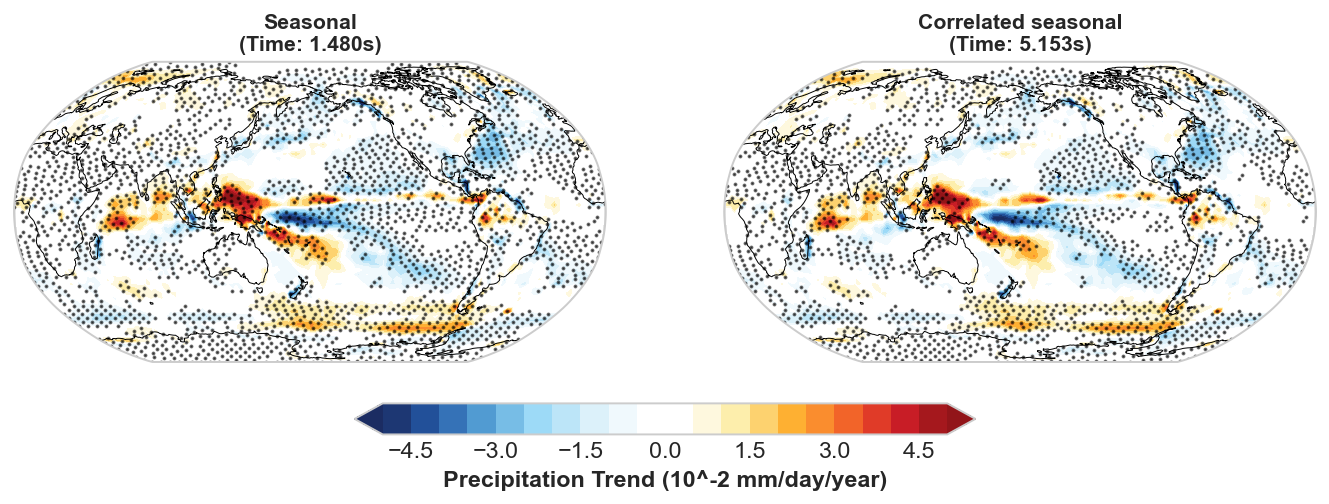

In [21]:
fig = plt.figure(figsize=(12, 4.8))
for idx, (test_name, label) in enumerate(seasonal_test_labels.items(), start=1):
    ax = plt.subplot(1, 2, idx, projection=ccrs.Robinson(central_longitude=180))
    ds = seasonal_family_results[test_name]["result"]
    im = plot_trend_panel(
        ax,
        ds["lon"].values,
        ds["lat"].values,
        ds["trend"].values * TREND_SCALE,
        ds["p"].values,
        f"{label}\n(Time: {seasonal_family_results[test_name]['elapsed']:.3f}s)",
    )

cbar = fig.colorbar(im, ax=fig.axes, orientation="horizontal", fraction=0.06, pad=0.08, extend="both")
cbar.set_label("Precipitation Trend (10^-2 mm/day/year)", fontweight="bold", fontsize=12)
plt.show()


## Notes

- The four-method benchmark intentionally keeps two loop-based baselines so the speed difference is visible on the same real field.
- The annual MK family figure uses annual means from `1979-2014`.
- The seasonal MK family figure keeps the monthly data and uses `period=12`.
- All significance masks are plotted with `skyborn.plot.scatter` rather than `Axes.scatter`, so the retained stipple density responds to the displayed map geometry.
